<a href="https://colab.research.google.com/github/arunapriyars/AIPM_Project.ipynb/blob/main/AIPM_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance PyPortfolioOpt scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 7.6 MB/s eta 0:00:00


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

from pypfopt import EfficientFrontier, risk_models, expected_returns

plt.style.use('ggplot')

In [3]:
stocks = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'TSLA']

data = yf.download(stocks, start='2021-01-01', end='2026-01-01')

prices = data['Close']

prices.head()

/tmp/ipykernel_1838/1149325326.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start='2021-01-01', end='2026-01-01')
[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,AMZN,GOOG,MSFT,TSLA
Date,,,,,
2021-01-04,125.740845,159.331497,85.656799,207.956161,243.256668
2021-01-05,127.295464,160.925507,86.285263,208.156738,245.036667
2021-01-06,123.010513,156.919006,86.006210,202.759354,251.993332
2021-01-07,127.208054,158.108002,88.581505,208.529297,272.013336
2021-01-08,128.306030,159.134995,89.570778,209.799835,293.339996


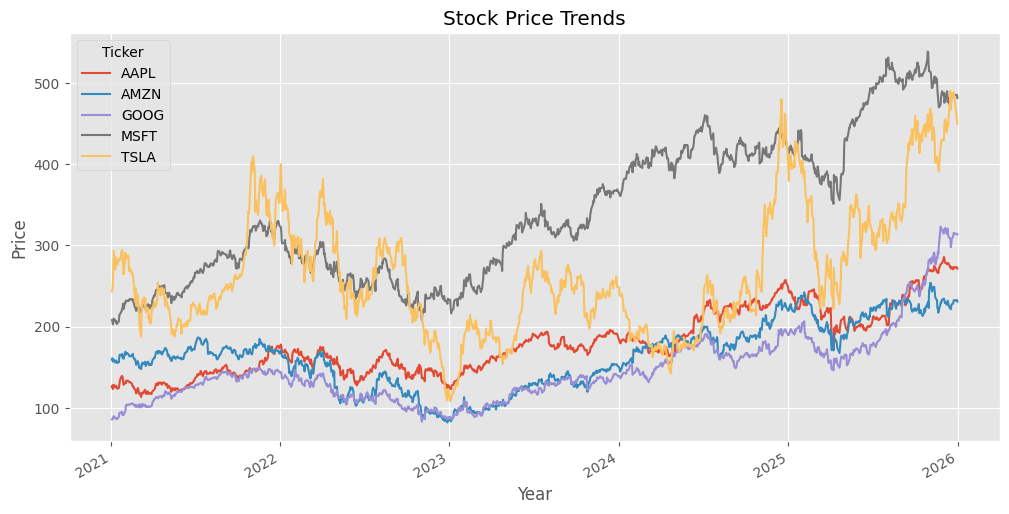

In [4]:
prices.plot(figsize=(12,6))
plt.title("Stock Price Trends")
plt.xlabel("Year")
plt.ylabel("Price")
plt.show()

In [5]:
returns = prices.pct_change()

returns.head()

risk = returns.std()
print("Risk (Volatility):\n", risk)

Risk (Volatility):
 Ticker
AAPL    0.017552
AMZN    0.022115
GOOG    0.019511
MSFT    0.016198
TSLA    0.038261
dtype: float64


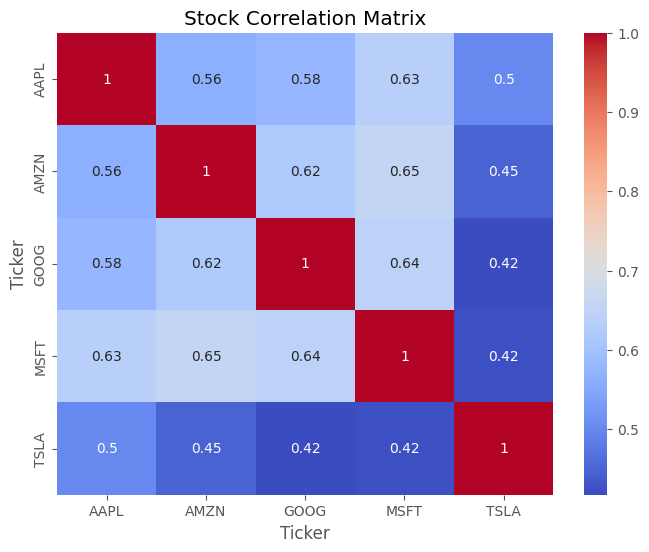

In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm')
plt.title("Stock Correlation Matrix")
plt.show()

In [7]:
df = yf.download('AAPL', start='2021-01-01', end='2026-01-01')

df = df[['Close']].copy()

df['Target'] = df['Close'].shift(-1)

df.dropna(inplace=True)

df.head()

/tmp/ipykernel_1838/258427241.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2021-01-01', end='2026-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,Target
Ticker,AAPL,
Date,,
2021-01-04,125.740845,127.295464
2021-01-05,127.295464,123.010513
2021-01-06,123.010513,127.208054
2021-01-07,127.208054,128.306030
2021-01-08,128.306030,125.323059


In [8]:
X = df[['Close']]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

RandomForestRegressor()

In [9]:
predictions = model.predict(X_test)

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("Model Performance")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 4))

Model Performance
MAE: 6.95
RMSE: 9.72
R² Score: 0.8654


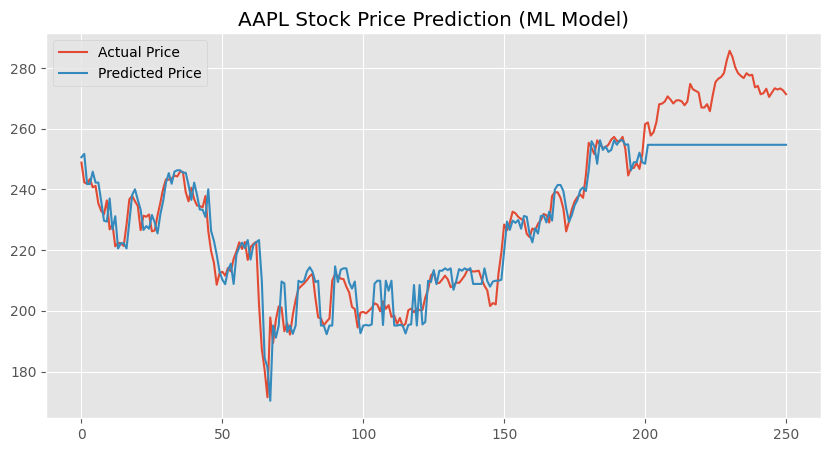

In [10]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.title("AAPL Stock Price Prediction (ML Model)")
plt.legend()
plt.show()

In [11]:
age = int(input("Enter Age: "))
income = int(input("Enter Annual Income: "))
risk = input("Enter Risk Level (Low / Medium / High): ")

Enter Age: 22
Enter Annual Income: 500000
Enter Risk Level (Low / Medium / High): Medium


In [12]:
if risk.lower() == "low":
    portfolio = {
        'Bonds': 60,
        'ETF': 30,
        'Stocks': 10
    }

elif risk.lower() == "medium":
    portfolio = {
        'Stocks': 50,
        'ETF': 30,
        'Bonds': 20
    }

else:
    portfolio = {
        'Stocks': 70,
        'ETF': 20,
        'Crypto': 10
    }

print("\nRecommended Portfolio Allocation:\n")

for k, v in portfolio.items():
    print(k, ":", v, "%")


Recommended Portfolio Allocation:

Stocks : 50 %
ETF : 30 %
Bonds : 20 %


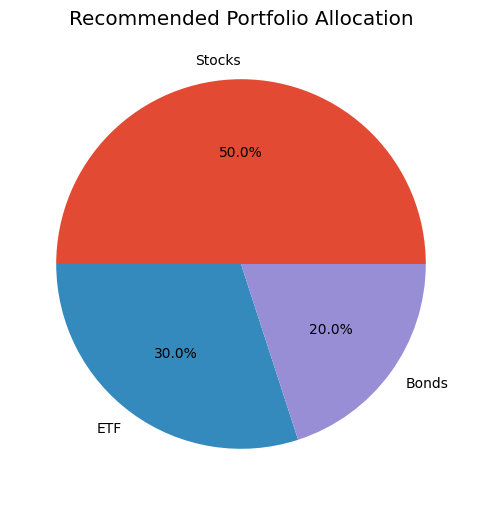

In [13]:
plt.figure(figsize=(6,6))

plt.pie(
    portfolio.values(),
    labels=portfolio.keys(),
    autopct='%1.1f%%'
)

plt.title("Recommended Portfolio Allocation")
plt.show()

In [14]:
mu = expected_returns.mean_historical_return(prices)
S = risk_models.sample_cov(prices)

In [15]:
ef = EfficientFrontier(mu, S)
weights = ef.max_sharpe()
cleaned_weights = ef.clean_weights()

print("Optimized Portfolio Weights:\n")
print(cleaned_weights)

Optimized Portfolio Weights:

OrderedDict({'AAPL': 0.0031, 'AMZN': 0.0, 'GOOG': 0.81244, 'MSFT': 0.18446, 'TSLA': 0.0})


In [16]:
ef.portfolio_performance(verbose=True)


Expected annual return: 27.6%
Annual volatility: 28.5%
Sharpe Ratio: 0.97


(np.float64(0.2763523985757191),
 np.float64(0.2850587258803266),
 np.float64(0.9694577765415867))

In [17]:
print("\nFINAL PROJECT SUMMARY")
print("----------------------")
print("1. ML Model: Random Forest for Stock Prediction")
print("2. Portfolio Optimization: Markowitz Model")
print("3. Risk Analysis: Based on historical volatility")
print("4. Recommendation System: Based on user risk profile")
print("5. Visualization: Stock trends + pie charts + correlation heatmap")


FINAL PROJECT SUMMARY
----------------------
1. ML Model: Random Forest for Stock Prediction
2. Portfolio Optimization: Markowitz Model
3. Risk Analysis: Based on historical volatility
4. Recommendation System: Based on user risk profile
5. Visualization: Stock trends + pie charts + correlation heatmap
